# IntiVision Dataset Collection

This notebook documents the data collection strategy used to build the IntiVision hand gesture dataset.

The goal is not to collect data inside the notebook, but to explain:

- which gesture classes were selected,
- how images were captured,
- how class balance was maintained,
- how the collection pipeline evolved,
- and how the final dataset was prepared for MediaPipe-based preprocessing.

## Gesture Classes

The dataset contains five gesture classes:

- `stop`
- `safe`
- `not_safe`
- `emergency`
- `help_code`

Each class represents a distinct hand gesture used by the realtime classification system.

In [4]:
GESTURE_CLASSES = [
    "stop",
    "safe",
    "not_safe",
    "emergency",
    "help_code",
]

GESTURE_CLASSES

['stop', 'safe', 'not_safe', 'emergency', 'help_code']

## Dataset Location

The raw dataset is stored in the following structure:

```text
dataset/
├── emergency/
├── help_code/
├── not_safe/
├── safe/
└── stop/

In [8]:

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATASET_DIR = PROJECT_ROOT / "dataset"

DATASET_DIR

PosixPath('/Users/serhaterbil/Desktop/intivision/ai-service/dataset')

In [9]:
dataset_counts = {
    class_name: len(list((DATASET_DIR / class_name).glob("*")))
    for class_name in GESTURE_CLASSES
}

dataset_counts

{'stop': 575, 'safe': 550, 'not_safe': 470, 'emergency': 550, 'help_code': 600}

In [10]:
total_images = sum(dataset_counts.values())

print("Total images:", total_images)

for class_name, count in dataset_counts.items():
    print(f"{class_name:12} {count}")

Total images: 2745
stop         575
safe         550
not_safe     470
emergency    550
help_code    600


## Class Distribution

A balanced dataset helps reduce class bias during training.

The following chart shows the number of images available for each gesture class.

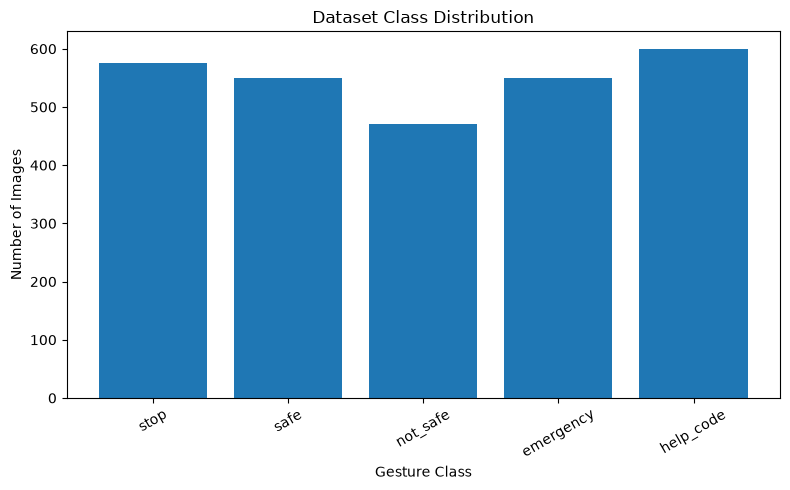

In [11]:
import matplotlib.pyplot as plt

class_names = list(dataset_counts.keys())
class_counts = list(dataset_counts.values())

plt.figure(figsize=(8, 5))
plt.bar(class_names, class_counts)
plt.title("Dataset Class Distribution")
plt.xlabel("Gesture Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [12]:
minimum_count = min(class_counts)
maximum_count = max(class_counts)
count_difference = maximum_count - minimum_count

print("Minimum class count:", minimum_count)
print("Maximum class count:", maximum_count)
print("Difference:", count_difference)

Minimum class count: 470
Maximum class count: 600
Difference: 130


## Random Samples from Each Class

Before training a model, it is important to visually inspect the dataset.

This helps identify issues such as:

- incorrect labels,
- poor image quality,
- inconsistent backgrounds,
- missing hand regions,
- lighting differences.

In [13]:
import random

import cv2
import matplotlib.pyplot as plt

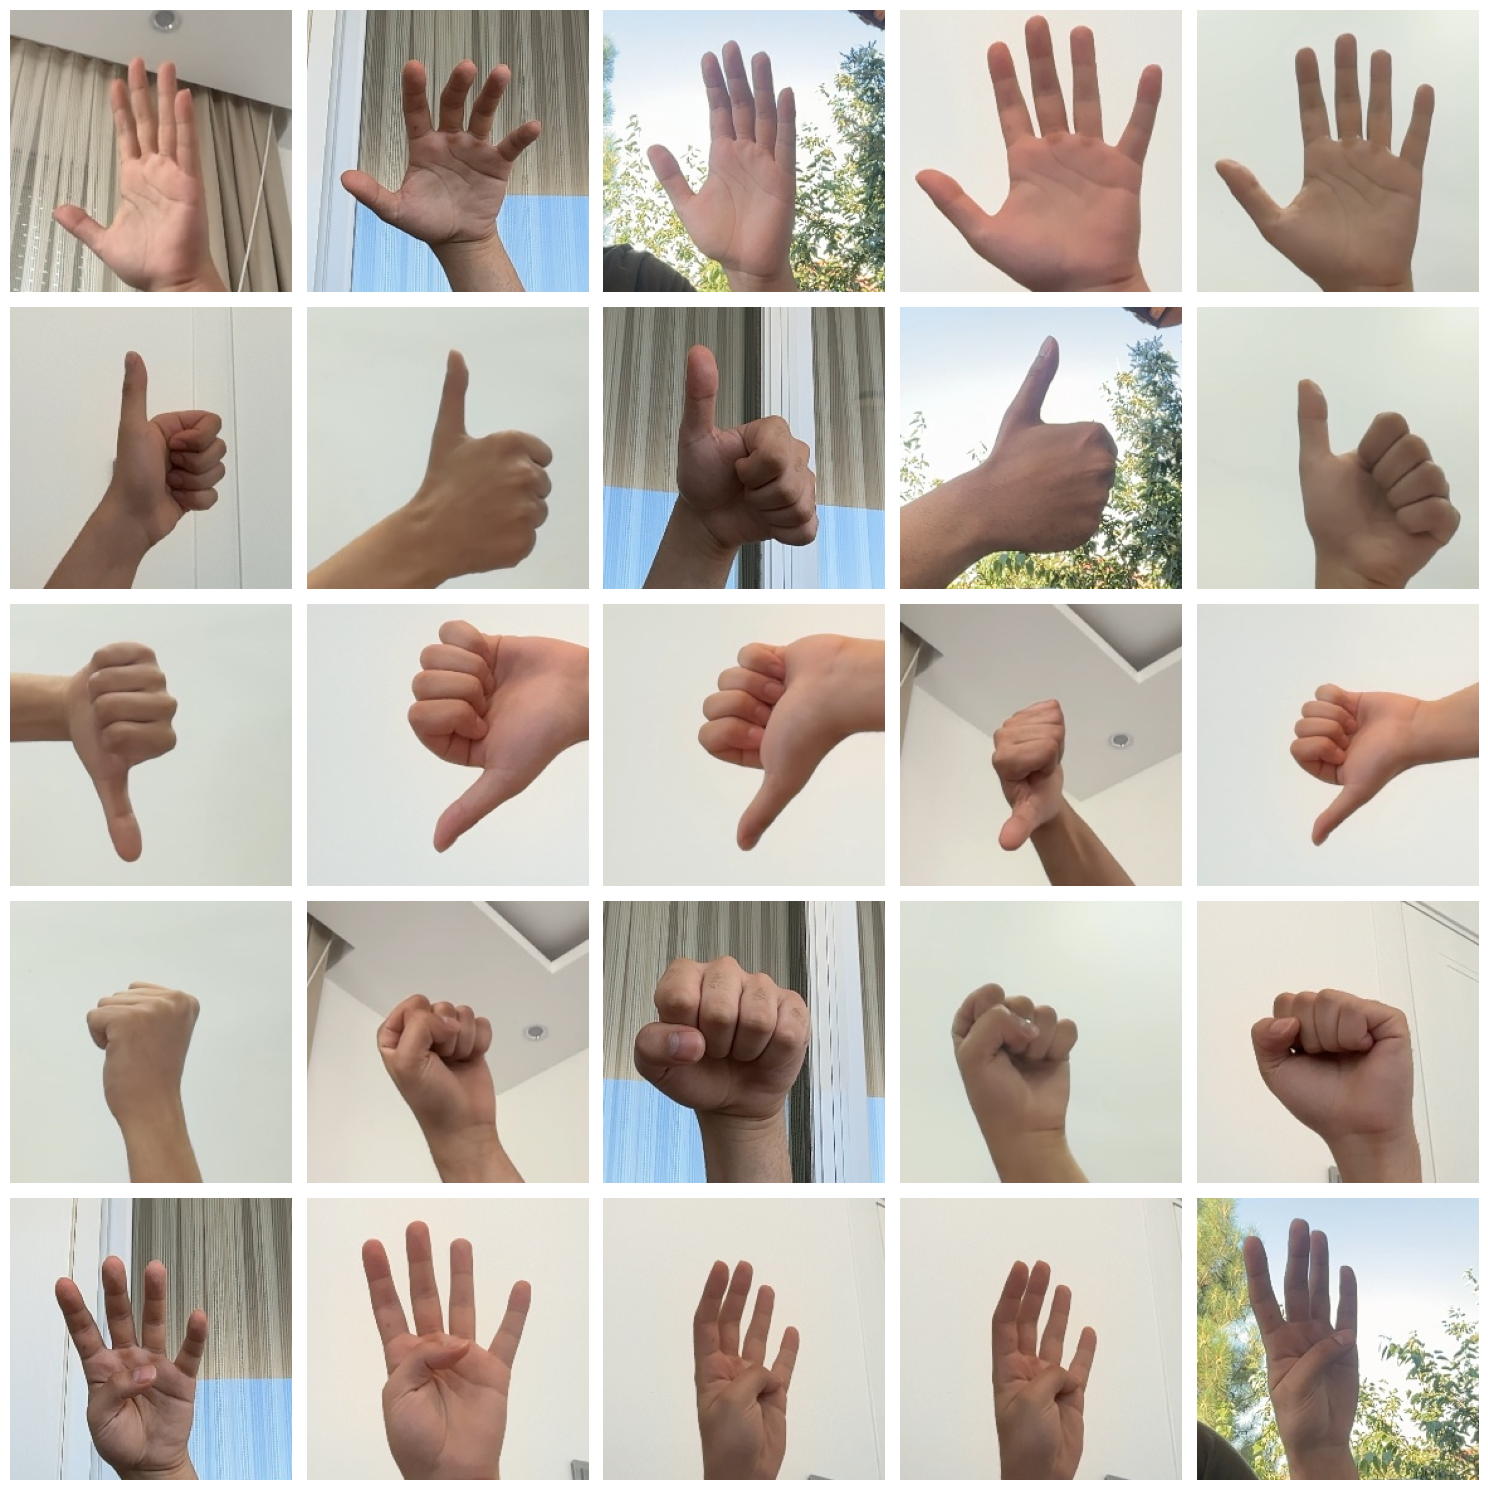

In [14]:
fig, axes = plt.subplots(
    len(GESTURE_CLASSES),
    5,
    figsize=(15, 15),
)

for row, gesture in enumerate(GESTURE_CLASSES):

    image_paths = list((DATASET_DIR / gesture).glob("*"))

    samples = random.sample(
        image_paths,
        min(5, len(image_paths)),
    )

    for col, image_path in enumerate(samples):

        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        axes[row, col].imshow(image)
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_ylabel(
                gesture,
                fontsize=12,
            )

plt.tight_layout()
plt.show()

## Image Resolution Analysis

The original dataset may contain images with different resolutions.

This section checks whether all collected images have consistent dimensions before preprocessing.

In [15]:
from collections import Counter

image_sizes = []

for gesture in GESTURE_CLASSES:

    for image_path in (DATASET_DIR / gesture).glob("*"):

        image = cv2.imread(str(image_path))

        height, width = image.shape[:2]

        image_sizes.append((width, height))

resolution_counter = Counter(image_sizes)

resolution_counter

Counter({(224, 224): 2745})

In [16]:
for resolution, count in resolution_counter.items():
    print(f"{resolution} -> {count} images")

(224, 224) -> 2745 images


In [17]:
most_common_resolution = resolution_counter.most_common(1)[0]

print("Most common resolution:")
print(most_common_resolution)

Most common resolution:
((224, 224), 2745)


## Data Collection Strategy

The dataset was collected manually using a webcam.

Several design decisions were made to improve the model's ability to generalize in real-world conditions.

Collection strategy:

- Images were collected class by class.
- Multiple recording sessions were performed.
- Different hand orientations were included.
- Slight variations in distance and rotation were intentionally introduced.
- The hand remained inside the ROI during capture.
- Images were automatically indexed to avoid overwriting existing samples.

## Dataset Summary

Final dataset statistics:

- Number of classes: 5
- Total images: 2745
- Collection method: Webcam
- ROI extraction: Manual collection → MediaPipe preprocessing
- Target image size: 224 × 224

In [18]:
print("========== DATASET SUMMARY ==========")
print(f"Classes        : {len(GESTURE_CLASSES)}")
print(f"Total Images   : {total_images}")
print(f"Image Size     : 224 x 224")
print(f"Dataset Folder : {DATASET_DIR}")

========== DATASET SUMMARY ==========
Classes        : 5
Total Images   : 2745
Image Size     : 224 x 224
Dataset Folder : /Users/serhaterbil/Desktop/intivision/ai-service/dataset


# Conclusion

The dataset is balanced across gesture classes and was visually inspected before model training.

This notebook focuses on documenting the data collection process rather than training the model.

Model training and evaluation are covered in the following notebooks.